K-Nearest Neighbors (KNN) Implementation


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

Defining the KNN Classifier



In [ ]:
class KNNClassifier:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        """
        KNN is a non-parametric model, so 'fitting' simply involves
        storing the training dataset.
        """
        self.X_train = np.array(X)
        self.y_train = np.array(y)

    def predict(self, X):
        """
        Predict labels for a batch of query data X.
        """
        X = np.array(X)
        predictions = [self._predict_single(x) for x in X]
        return np.array(predictions)

    def _predict_single(self, x):
        # 1. Compute Euclidean distances from x to all points in self.X_train
        distances = np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))

        # 2. Get the indices of the self.k smallest distances
        k_indices = np.argsort(distances)[:self.k]

        # 3. Get the labels of those k neighbors
        k_nearest_labels = self.y_train[k_indices]

        # 4. Return the most common label among them
        most_common = Counter(k_nearest_labels).most_common(1)
        return most_common[0][0]

Generating Synthetic Dataset and Evaluation


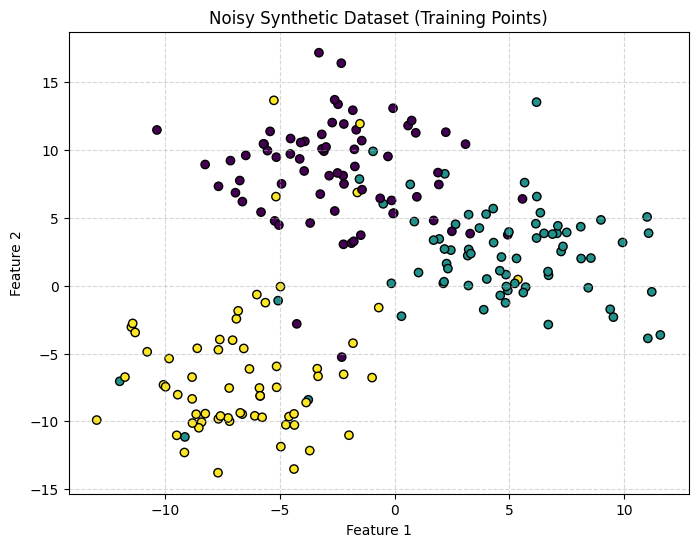

In [ ]:
# Generate a 3-class classification dataset with increased cluster standard deviation (overlap)
X, y = make_blobs(n_samples=300, n_features=2, centers=3, cluster_std=3.0, random_state=42)

# Introduce 10% label noise to prevent perfect classification
np.random.seed(42)
noise_mask = np.random.rand(len(y)) < 0.10
y[noise_mask] = np.random.randint(0, 3, size=noise_mask.sum())

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Plot the training dataset
plt.figure(figsize=(8, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='viridis', edgecolor='k', marker='o', label='Train Data')
plt.title("Noisy Synthetic Dataset (Training Points)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Training and Evaluation



In [ ]:
# Instantiate and fit our model on the noisy dataset
knn = KNNClassifier(k=5)
knn.fit(X_train, y_train)

# Get predictions
y_pred = knn.predict(X_test)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Set Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Test Set Accuracy: 93.33%

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93        30
           1       0.92      0.89      0.91        27
           2       0.94      0.97      0.96        33

    accuracy                           0.93        90
   macro avg       0.93      0.93      0.93        90
weighted avg       0.93      0.93      0.93        90

